In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#data cleaning


In [14]:
df = df.drop_duplicates()
df['country']=df['country'].fillna("unknown")
df['director']=df['director'].fillna("unknown")
df['cast']=df['cast'].fillna("unknown")


In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [16]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


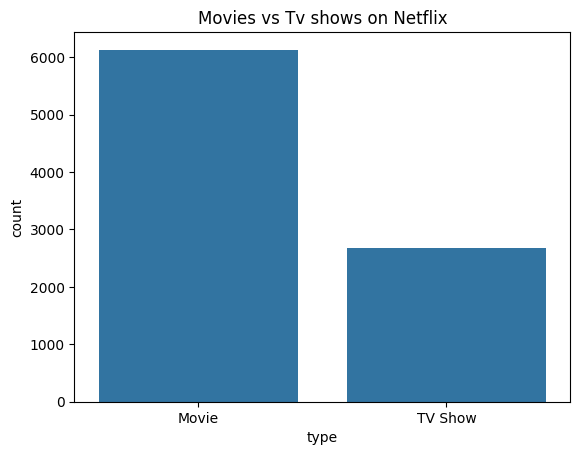

In [29]:
sns.countplot(x='type',data=df)
plt.title("Movies vs Tv shows on Netflix")
plt.savefig("Movies vs Tv shows on Netflix")
plt.show()

top countries producing content


In [18]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


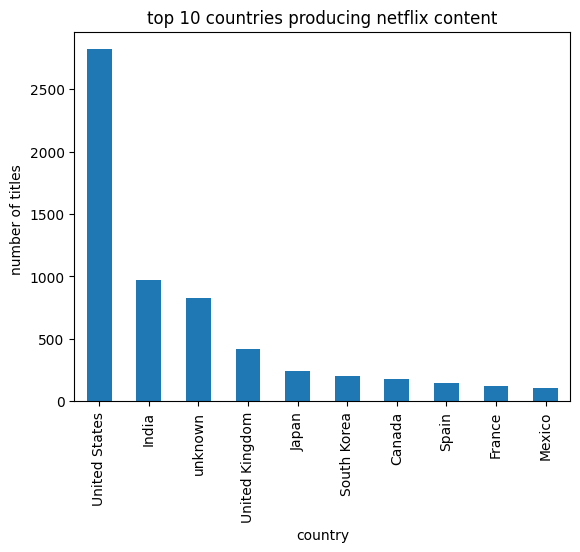

In [30]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("top 10 countries producing netflix content")
plt.xlabel("country")
plt.ylabel("number of titles ")
plt.savefig("top 10 countries producing netflix content")
plt.show()

content growth over time

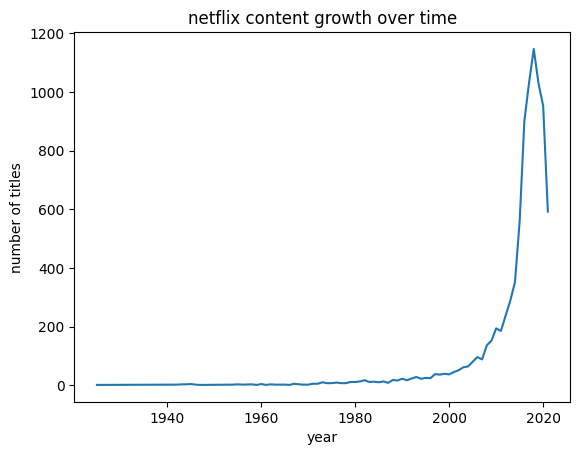

In [31]:
df['release_year'].value_counts().sort_index().plot()
plt.title("netflix content growth over time")
plt.xlabel("year")
plt.ylabel("number of titles")
plt.savefig("netflix content growth over time")
plt.show()


In [22]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


the year netflix added the most content

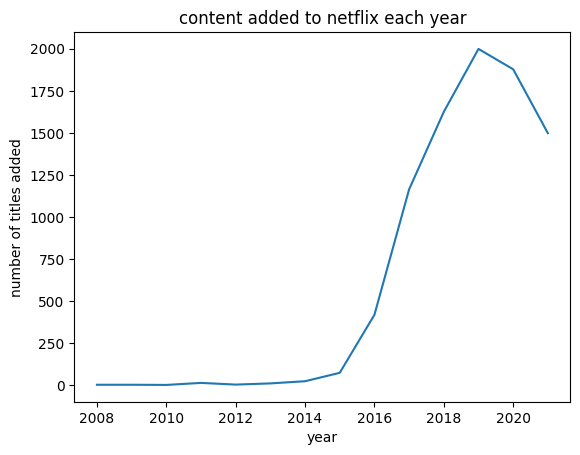

In [32]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['year_added']=df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot()
plt.title("content added to netflix each year")
plt.xlabel("year")
plt.ylabel("number of titles added")
plt.savefig("content added to netflix each year")
plt.show()

In [26]:
df['year_added']=df['date_added'].dt.year

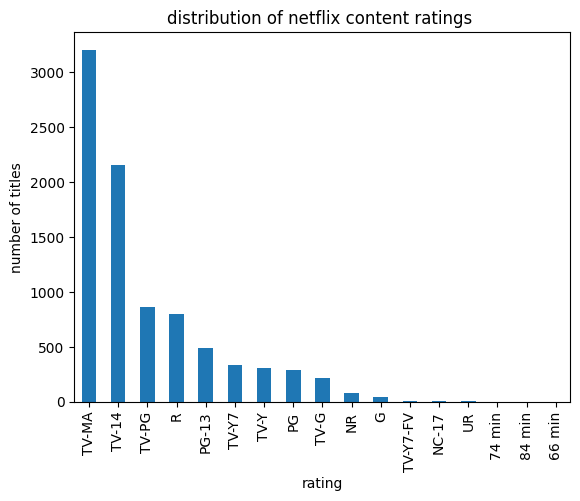

In [33]:
df['rating'].value_counts().plot(kind='bar')
plt.title("distribution of netflix content ratings ")
plt.xlabel("rating")
plt.ylabel("number of titles")
plt.savefig("distribution of netflix content ratings ")
plt.show()

In [34]:
df.shape

(8807, 13)